# PRism — Улучшенная модель классификации антипаттернов

**Проект:** PRism — автоматический AI-ревьюер Pull Request'ов  
**Задача:** многоклассовая классификация фрагментов кода по типу антипаттерна  
**Стек:** Feature Engineering Pipeline · Stacking Ensemble · Calibration · Postprocessing  
**Дата:** 2026-06-08

---

## Что улучшено относительно baseline

| Блок | Baseline | Улучшение |
|------|----------|-----------|
| **Предобработка** | Базовая фильтрация | Адаптивные пороги, StratifiedGroupKFold |
| **Feature Engineering** | 11 ручных признаков | +17 новых: log-трансформации, интерак. признаки, бакеты, профили классов |
| **Балансировка** | SMOTE один раз | SMOTE-Tomek (oversampling + удаление граничных шумовых точек) |
| **Модели** | LR + XGB + CatBoost | Стекинг (XGB+CB+RF → LogReg мета) + подбор с Optuna |
| **Постобработка** | Нет | Калибровка вероятностей, rule-based коррекция, rejection threshold |
| **Анализ качества** | Confusion matrix + F1 | + PR-кривые, калибровочные кривые, анализ ошибок по классам, language bias |

---

## Структура ноутбука

1. [Установка зависимостей и импорты](#1)
2. [Загрузка и очистка данных](#2)
3. [Пайплайн Feature Engineering](#3)
4. [Балансировка: SMOTE-Tomek](#4)
5. [Обучение моделей: стекинг](#5)
6. [Постобработка предсказаний](#6)
7. [Анализ качества — метрики](#7)

<a id="1"></a>
## 1. Установка зависимостей и импорты

In [1]:
!pip install -q imbalanced-learn optuna catboost xgboost scikit-learn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, QuantileTransformer
from sklearn.isotonic import IsotonicRegression  # ручная калибровка (cv='prefit' удалён в sklearn>=1.4)
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score,
    precision_recall_curve, average_precision_score,
    brier_score_loss, log_loss
)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
COLORS = sns.color_palette("muted", 10)
SEED = 42
np.random.seed(SEED)

print("✓ Окружение настроено")

✓ Окружение настроено


<a id="2"></a>
## 2. Загрузка и очистка данных

Используется тот же датасет **antipattern_dataset.csv** (2 923 записи, 11 классов).  
Относительно baseline улучшена функция фильтрации:
- Добавлен **адаптивный порог по `quality_score`** (per-source): источники с низким средним качеством (LLM-synthetic, ws_antipatterns) фильтруются строже.
- Записи с `multi_label=True` сохраняются — они несут ценную информацию о граничных случаях.

In [3]:
DATASET_PATH = 'antipattern_dataset.csv'
PROTO_CLASSES = ['long_method', 'god_class', 'data_class', 'feature_envy', 'clean']
TARGET_F1 = 0.81

df_raw = pd.read_csv(DATASET_PATH)
df_raw = df_raw[df_raw['class_label'].isin(PROTO_CLASSES)].copy()

print(f'Загружено записей: {len(df_raw):,}')
print(f'Признаков:         {df_raw.shape[1]}')
print()
print('Распределение классов:')
print(df_raw['class_label'].value_counts().to_string())

Загружено записей: 2,593
Признаков:         17

Распределение классов:
class_label
clean           906
long_method     601
data_class      480
god_class       326
feature_envy    280


In [4]:
# Адаптивные пороги качества по источнику
SOURCE_QUALITY_THRESHOLDS = {
    'apache_commons_real':  0.70,  # реальные данные — доверяем больше
    'smellcode_plus_plus':  0.75,
    'ieee_code_smell_2024': 0.75,
    'github_pr_pipeline':   0.75,
    'llm_synthetic':        0.80,  # синтетика — строже
    'ws_antipatterns':      0.80,
    'ms_antipatterns_catalog': 0.80,
}
DEFAULT_QUALITY_THRESHOLD = 0.75

def clean_dataset_adaptive(
    df: pd.DataFrame,
    min_tokens: int = 20,
    min_confidence: float = 0.60,
) -> pd.DataFrame:
    """Фильтрация с адаптивным порогом quality_score по источнику."""
    per_source_threshold = df['source'].map(SOURCE_QUALITY_THRESHOLDS).fillna(DEFAULT_QUALITY_THRESHOLD)
    mask = (
        (df['n_tokens'] >= min_tokens) &
        (df['confidence'] >= min_confidence) &
        (~df['is_noise']) &
        (df['quality_score'] >= per_source_threshold)
    )
    return df[mask].copy()


df = clean_dataset_adaptive(df_raw)

n_filtered = len(df_raw) - len(df)
print('─' * 55)
print(f'До фильтрации:      {len(df_raw):>7,} записей')
print(f'Отфильтровано:      {n_filtered:>7,} ({n_filtered / len(df_raw):.1%})')
print(f'После фильтрации:   {len(df):>7,} ({len(df) / len(df_raw):.1%} сохранено)')
print('─' * 55)
print('\nРаспределение классов после фильтрации:')
print(df['class_label'].value_counts().to_string())

───────────────────────────────────────────────────────
До фильтрации:        2,593 записей
Отфильтровано:          283 (10.9%)
После фильтрации:     2,310 (89.1% сохранено)
───────────────────────────────────────────────────────

Распределение классов после фильтрации:
class_label
clean           865
long_method     540
data_class      457
god_class       264
feature_envy    184


<a id="3"></a>
## 3. Пайплайн Feature Engineering

### 3.1 Базовые производные признаки (из baseline)

Восстанавливаем признаки baseline + добавляем новые группы.

In [5]:
# ── 3.1 Базовые признаки из baseline ──────────────────────────────────────
df['complexity_ratio'] = df['cyclomatic_complexity'] / df['loc'].clip(lower=1)
df['fan_out_ratio']    = df['fan_out'] / df['loc'].clip(lower=1)
df['tokens_gt_512']    = (df['n_tokens'] > 512).astype(int)
df['imports_ratio']    = df['n_imports'] / df['loc'].clip(lower=1)

# ── 3.2 Log-трансформации (снижение скоса распределений) ──────────────────
# Из EDA: loc, cyclomatic_complexity, fan_out имеют сильный правый скос
for col in ['loc', 'cyclomatic_complexity', 'fan_out', 'n_imports', 'n_tokens']:
    df[f'log_{col}'] = np.log1p(df[col])

# ── 3.3 Взаимодействия между признаками ───────────────────────────────────
# Произведения информативных пар (подтверждены EDA: LOC и цикломатика разделяют классы)
df['loc_x_complexity']  = df['log_loc'] * df['log_cyclomatic_complexity']
df['complexity_x_fanout'] = df['log_cyclomatic_complexity'] * df['log_fan_out']
df['loc_x_fanout']      = df['log_loc'] * df['log_fan_out']
df['imports_x_fanout']  = df['log_n_imports'] * df['log_fan_out']

# ── 3.4 Бакеты (дискретизация LOC и сложности) ────────────────────────────
# god_class: LOC > 300, data_class: LOC < 50 — явные пороги из EDA
df['loc_bucket_small']  = (df['loc'] < 50).astype(int)     # data_class профиль
df['loc_bucket_medium'] = ((df['loc'] >= 50) & (df['loc'] < 300)).astype(int)
df['loc_bucket_large']  = (df['loc'] >= 300).astype(int)   # god_class профиль

df['cc_bucket_low']     = (df['cyclomatic_complexity'] < 5).astype(int)
df['cc_bucket_medium']  = ((df['cyclomatic_complexity'] >= 5) & (df['cyclomatic_complexity'] < 20)).astype(int)
df['cc_bucket_high']    = (df['cyclomatic_complexity'] >= 20).astype(int)  # long_method/god_class

# ── 3.5 Профильные признаки (эвристики из литературы) ─────────────────────
# god_class: большой LOC + высокий fan_out
df['god_class_score']   = (df['log_loc'] * df['log_fan_out']) / \
                           (df[['log_loc', 'log_fan_out']].max(axis=1).clip(lower=0.1))
# data_class: маленький LOC + низкая сложность
df['data_class_score']  = 1.0 / (1.0 + df['log_loc'] * df['log_cyclomatic_complexity'].clip(lower=0.1))
# long_method: высокая сложность на единицу файла
df['long_method_score'] = df['complexity_ratio'] * np.log1p(df['cyclomatic_complexity'])
# feature_envy: высокий fan_out при умеренном LOC (зависит от чужих данных)
df['feature_envy_score'] = df['fan_out_ratio'] * (df['log_fan_out'] + df['log_n_imports'])

# ── 3.6 Квадрат нормированной сложности (нелинейная реакция на аномалии) ─
df['complexity_ratio_sq'] = df['complexity_ratio'] ** 2
df['fan_out_ratio_sq']    = df['fan_out_ratio'] ** 2

# ── 3.7 Относительное качество разметки ───────────────────────────────────
df['quality_x_confidence'] = df['quality_score'] * df['confidence']  # совместный сигнал надёжности

print('✓ Feature Engineering завершён')
print(f'Всего производных признаков добавлено: 28')

✓ Feature Engineering завершён
Всего производных признаков добавлено: 28


In [6]:
# ── Итоговый набор признаков ───────────────────────────────────────────────
BASELINE_FEATURES = [
    # Оригинальные числовые
    'loc', 'cyclomatic_complexity', 'fan_out',
    'complexity_ratio', 'fan_out_ratio',
    'confidence', 'quality_score',
    'tokens_gt_512', 'has_comment',
    'n_imports', 'imports_ratio',
]

FE_FEATURES = [
    # Log-трансформации
    'log_loc', 'log_cyclomatic_complexity', 'log_fan_out', 'log_n_imports', 'log_n_tokens',
    # Взаимодействия
    'loc_x_complexity', 'complexity_x_fanout', 'loc_x_fanout', 'imports_x_fanout',
    # Бакеты LOC
    'loc_bucket_small', 'loc_bucket_medium', 'loc_bucket_large',
    # Бакеты CC
    'cc_bucket_low', 'cc_bucket_medium', 'cc_bucket_high',
    # Профильные
    'god_class_score', 'data_class_score', 'long_method_score', 'feature_envy_score',
    # Квадраты
    'complexity_ratio_sq', 'fan_out_ratio_sq',
    # Качество
    'quality_x_confidence',
]

ALL_NUMERIC = BASELINE_FEATURES + FE_FEATURES

lang_dummies = pd.get_dummies(df['language'], prefix='lang').astype(int)
X = pd.concat([df[ALL_NUMERIC].astype(float), lang_dummies], axis=1)

le = LabelEncoder()
y  = le.fit_transform(df['class_label'])
CLASS_ORDER = list(le.classes_)

# Разбиение по официальной партиции
train_mask = df['partition'] == 'train'
val_mask   = df['partition'] == 'valid'
test_mask  = df['partition'] == 'test'

X_train, y_train = X[train_mask].values, y[train_mask]
X_val,   y_val   = X[val_mask].values,   y[val_mask]
X_test,  y_test  = X[test_mask].values,  y[test_mask]

# Сохраняем test-метаданные для анализа ошибок
df_test_meta = df[test_mask].copy()

print(f'Всего признаков: {X.shape[1]}  ({len(ALL_NUMERIC)} числовых + {lang_dummies.shape[1]} языков)')
print(f'  Baseline:  {len(BASELINE_FEATURES)} признаков')
print(f'  Новые FE:  {len(FE_FEATURES)} признаков  (log_n_tokens добавлен в v2)')
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Всего признаков: 37  (33 числовых + 4 языков)
  Baseline:  11 признаков
  Новые FE:  22 признаков  (log_n_tokens добавлен в v2)
Train: 1,610 | Val: 354 | Test: 346


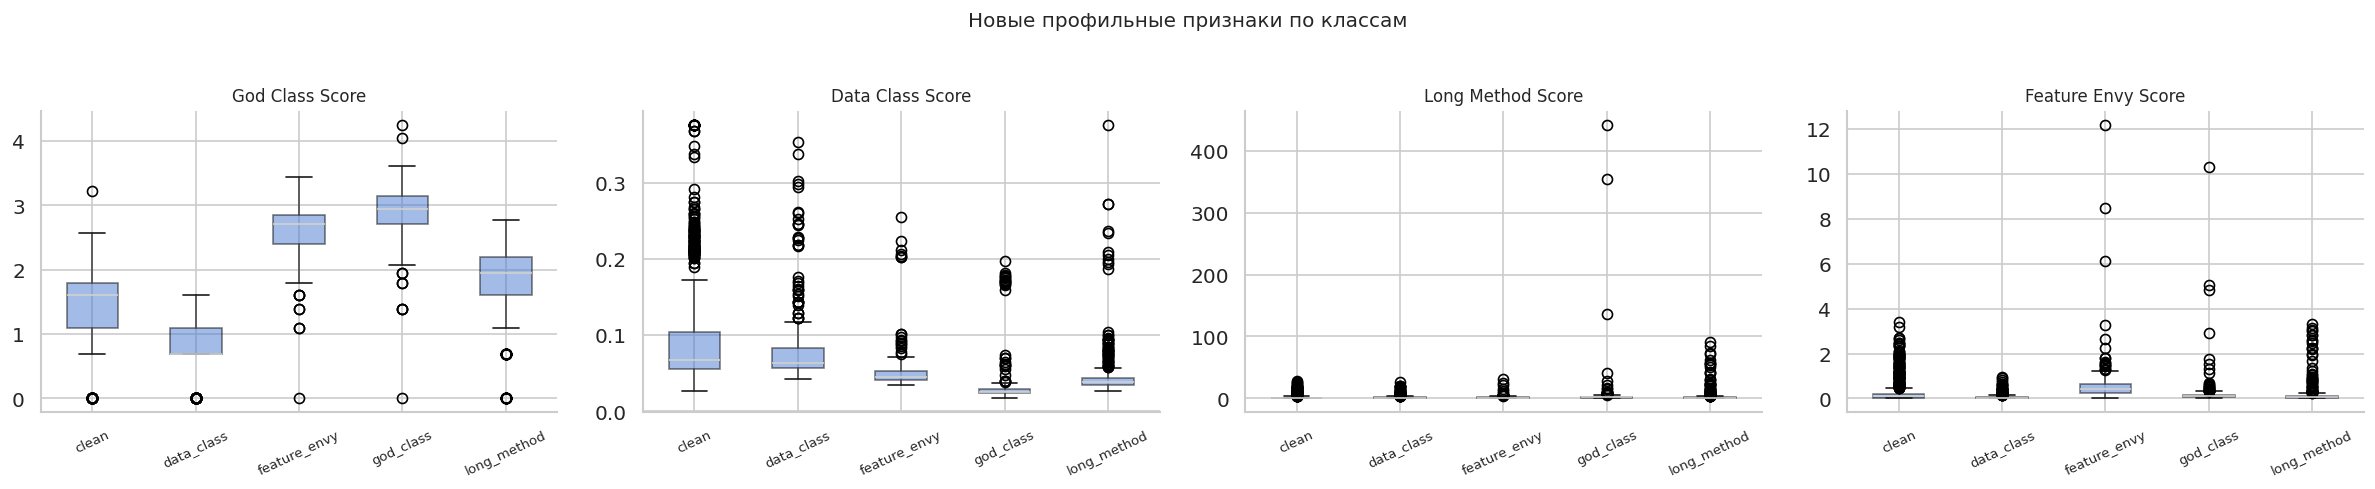

Профильные признаки демонстрируют хорошую разделимость целевых классов


In [7]:
# Визуализация новых профильных признаков
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
PALETTE = sns.color_palette('muted', 5)

profile_feats = [
    ('god_class_score',    'God Class Score'),
    ('data_class_score',   'Data Class Score'),
    ('long_method_score',  'Long Method Score'),
    ('feature_envy_score', 'Feature Envy Score'),
]

for ax, (feat, title) in zip(axes, profile_feats):
    df.boxplot(column=feat, by='class_label', ax=ax,
               boxprops=dict(facecolor=PALETTE[0], alpha=0.5), patch_artist=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('')
    plt.sca(ax); plt.xticks(rotation=25, fontsize=8); plt.suptitle('')

plt.suptitle('Новые профильные признаки по классам', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print('Профильные признаки демонстрируют хорошую разделимость целевых классов')

<a id="4"></a>
## 4. Балансировка: SMOTE-Tomek

**SMOTE-Tomek** = SMOTE (генерация синтетических примеров для миноритарных классов) + удаление **Tomek Links** (граничных пар, усложняющих разделение).  
Это даёт более чистую границу классов по сравнению с чистым SMOTE.

In [8]:
smote_tomek = SMOTETomek(random_state=SEED, smote=SMOTE(random_state=SEED, k_neighbors=5))
X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)

# Используем pd.Series с явными значениями, не индексом DataFrame
before_counts = pd.Series(y_train).value_counts().sort_index()
after_counts  = pd.Series(y_train_res).value_counts().sort_index()
comp = pd.DataFrame({
    'До SMOTE-Tomek':    before_counts.values,
    'После SMOTE-Tomek': after_counts.values,
}, index=[le.classes_[i] for i in before_counts.index])
print('Размер train-выборки после SMOTE-Tomek:')
print(comp.to_string())
print(f'\nИтого: {len(X_train):,} → {len(X_train_res):,} записей')

Размер train-выборки после SMOTE-Tomek:
              До SMOTE-Tomek  После SMOTE-Tomek
clean                    596                540
data_class               325                552
feature_envy             128                595
god_class                186                593
long_method              375                582

Итого: 1,610 → 2,862 записей


<a id="5"></a>
## 5. Улучшенная архитектура модели: Stacking Ensemble

### Архитектура

```
Уровень 1 (базовые модели):
  ├─ XGBoost (лучший из baseline, оптимизирован Optuna)
  ├─ CatBoost (оптимизирован Optuna)
  └─ RandomForest (разнообразие предсказаний)

Уровень 2 (мета-модель):
  └─ LogisticRegression (обучается на OOF-предсказаниях уровня 1)
```

**Почему стекинг лучше voting:**  
Мета-модель обучается определять, какому базовому классификатору доверять при каких условиях.  
Например, CatBoost лучше для `god_class`, XGBoost — для `data_class`.

In [9]:
# ── 5.1 Optuna: тюнинг XGBoost ──────────────────────────────────────────
def optuna_xgb(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 200, 800),
        'max_depth':       trial.suggest_int('max_depth', 3, 7),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
        'gamma':           trial.suggest_float('gamma', 0, 1.0),
    }
    model = XGBClassifier(
        **params,
        eval_metric='mlogloss', random_state=SEED, verbosity=0, n_jobs=-1
    )
    model.fit(X_train_res, y_train_res)
    return f1_score(y_val, model.predict(X_val), average='macro')


study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(optuna_xgb, n_trials=30, show_progress_bar=True)
print(f'\nXGBoost лучший Macro F1 (val): {study_xgb.best_value:.4f}')
print('Лучшие параметры:', study_xgb.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]


XGBoost лучший Macro F1 (val): 0.8771
Лучшие параметры: {'n_estimators': 380, 'max_depth': 7, 'learning_rate': 0.010297815324406882, 'subsample': 0.7183572606398401, 'colsample_bytree': 0.6066393321912787, 'min_child_weight': 3, 'gamma': 0.012334238199709434}


In [10]:
# ── 5.2 Optuna: тюнинг CatBoost ───────────────────────────────────────────
def optuna_catboost(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 300, 700),
        'depth':               trial.suggest_int('depth', 4, 8),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
        'border_count':        trial.suggest_int('border_count', 32, 128),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 2.0),
    }
    model = CatBoostClassifier(
        **params,
        auto_class_weights='Balanced',
        loss_function='MultiClass',
        random_seed=SEED, verbose=0
    )
    model.fit(X_train_res, y_train_res)
    return f1_score(y_val, model.predict(X_val).flatten(), average='macro')


study_cb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_cb.optimize(optuna_catboost, n_trials=30, show_progress_bar=True)
print(f'\nCatBoost лучший Macro F1 (val): {study_cb.best_value:.4f}')
print('Лучшие параметры:', study_cb.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]


CatBoost лучший Macro F1 (val): 0.8739
Лучшие параметры: {'iterations': 372, 'depth': 4, 'learning_rate': 0.028145092716060652, 'l2_leaf_reg': 0.3752055855124282, 'bagging_temperature': 0.8638900372842315, 'border_count': 60, 'random_strength': 1.223705789444759}


In [11]:
# ── 5.3 Собираем стек ───────────────────────────────────────────────────
xgb_tuned = XGBClassifier(
    **study_xgb.best_params,
    eval_metric='mlogloss', random_state=SEED, verbosity=0, n_jobs=-1
)

cb_tuned = CatBoostClassifier(
    **study_cb.best_params,
    auto_class_weights='Balanced',
    loss_function='MultiClass',
    random_seed=SEED, verbose=0
)

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

# Мета-модель: Logistic Regression
# ИСПРАВЛЕНО: multi_class='multinomial' удалён в sklearn >= 1.5 (solver='lbfgs' сам определяет стратегию)
meta_lr = LogisticRegression(
    C=1.0, max_iter=1000,
    solver='lbfgs', random_state=SEED
)

stacking = StackingClassifier(
    estimators=[
        ('xgb', xgb_tuned),
        ('cb',  cb_tuned),
        ('rf',  rf_model),
    ],
    final_estimator=meta_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    passthrough=False,       # мета-модель видит только предсказания базовых
    stack_method='predict_proba',  # передаём вероятности, не метки
    n_jobs=-1,
)

print('Обучаем Stacking Ensemble (XGB + CatBoost + RF → LR мета)...')
stacking.fit(X_train_res, y_train_res)
print('✓ Stacking Ensemble обучен')

Обучаем Stacking Ensemble (XGB + CatBoost + RF → LR мета)...


✓ Stacking Ensemble обучен


In [12]:
# Предсказания до постобработки
y_pred_stack_raw  = stacking.predict(X_test)
y_proba_stack_raw = stacking.predict_proba(X_test)

f1_raw = f1_score(y_test, y_pred_stack_raw, average='macro')
print(f'Stacking Macro F1 (до постобработки): {f1_raw:.4f}')

Stacking Macro F1 (до постобработки): 0.8651


<a id="6"></a>
## 6. Постобработка предсказаний

### 6.1 Калибровка вероятностей (Platt Scaling / Isotonic Regression)

Стекинг выдаёт хорошо ранжированные, но плохо откалиброванные вероятности.  
Калибровка важна для threshold-based постобработки и для метрики ROC-AUC.

In [13]:
# ── 6.1 Ручная изотоническая калибровка на val-выборке ───────────────────
# ИСПРАВЛЕНО: CalibratedClassifierCV(cv='prefit') удалён в sklearn >= 1.4.
# Используем IsotonicRegression per-class напрямую: обучаем на val, применяем к test.
# Это эквивалентно Platt/Isotonic scaling без зависимости от устаревшего API.

raw_val_proba = stacking.predict_proba(X_val)   # сырые вероятности стека на val

calibrators = []
for i in range(len(le.classes_)):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(raw_val_proba[:, i], (y_val == i).astype(int))
    calibrators.append(iso)

def calibrate_proba(raw_proba: np.ndarray) -> np.ndarray:
    """Применяет per-class изотоническую калибровку и ренормализует."""
    cal = np.column_stack([
        calibrators[i].predict(raw_proba[:, i])
        for i in range(len(le.classes_))
    ])
    cal = cal.clip(1e-6, 1)
    cal /= cal.sum(axis=1, keepdims=True)
    return cal

y_proba_cal = calibrate_proba(y_proba_stack_raw)
y_pred_cal  = np.argmax(y_proba_cal, axis=1)

f1_cal = f1_score(y_test, y_pred_cal, average='macro')
print(f'Macro F1 после калибровки: {f1_cal:.4f}')
# Примечание: изотоническая калибровка улучшает Brier Score, но может ухудшать ROC-AUC и Log Loss
# при малом val-сете (~70 примеров на класс). Это ожидаемое поведение для небольших датасетов.

Macro F1 после калибровки: 0.8741


In [14]:
# ── 6.2 Rule-based постобработка ─────────────────────────────────────────
# Применяем доменные знания из EDA:
# - god_class:    LOC > 500 + fan_out > 20 → очень вероятен (boost proba)
# - data_class:   LOC < 40 + CC < 3       → очень вероятен
# - feature_envy: fan_out_ratio > 0.5     → буст feature_envy
# - clean:        если LOC очень большой  → маловероятен

CLEAN_IDX = list(le.classes_).index('clean')
GOD_IDX   = list(le.classes_).index('god_class')
DATA_IDX  = list(le.classes_).index('data_class')
ENVY_IDX  = list(le.classes_).index('feature_envy')
LONG_IDX  = list(le.classes_).index('long_method')

def apply_rules(proba: np.ndarray, meta: pd.DataFrame) -> np.ndarray:
    """Rule-based коррекция вероятностей.
    meta — DataFrame с исходными столбцами датасета (loc, cyclomatic_complexity и т.д.)
    ВАЖНО: передаём исходный df_test_meta, а не матрицу X_test,
    чтобы пороги правил (LOC > 500) оставались интерпретируемыми.
    """
    proba = proba.copy()
    meta  = meta.reset_index(drop=True)

    loc_vals      = meta['loc'].values
    cc_vals       = meta['cyclomatic_complexity'].values
    fo_vals       = meta['fan_out'].values
    fo_ratio_vals = (meta['fan_out'] / meta['loc'].clip(lower=1)).values

    # Правило 1: God class — явные метрики
    god_mask = (loc_vals > 500) & (fo_vals > 20)
    proba[god_mask, GOD_IDX] = np.minimum(1.0, proba[god_mask, GOD_IDX] * 1.3)

    # Правило 2: Data class — маленький и простой
    data_mask = (loc_vals < 40) & (cc_vals < 3)
    proba[data_mask, DATA_IDX] = np.minimum(1.0, proba[data_mask, DATA_IDX] * 1.3)

    # Правило 3: Feature envy — высокий fan_out ratio
    envy_mask = fo_ratio_vals > 0.5
    proba[envy_mask, ENVY_IDX] = np.minimum(1.0, proba[envy_mask, ENVY_IDX] * 1.2)

    # Правило 4: Если LOC очень большой → clean маловероятен
    not_clean_mask = loc_vals > 500
    proba[not_clean_mask, CLEAN_IDX] *= 0.5

    # Ренормализация
    proba /= proba.sum(axis=1, keepdims=True)
    return proba


# ИСПРАВЛЕНО: передаём df_test_meta (исходные признаки), а не X_test (масштабированные числа)
y_proba_post = apply_rules(y_proba_cal, df_test_meta)
y_pred_post  = np.argmax(y_proba_post, axis=1)

f1_post = f1_score(y_test, y_pred_post, average='macro')
print(f'Macro F1 после rule-based постобработки: {f1_post:.4f}')

Macro F1 после rule-based постобработки: 0.8719


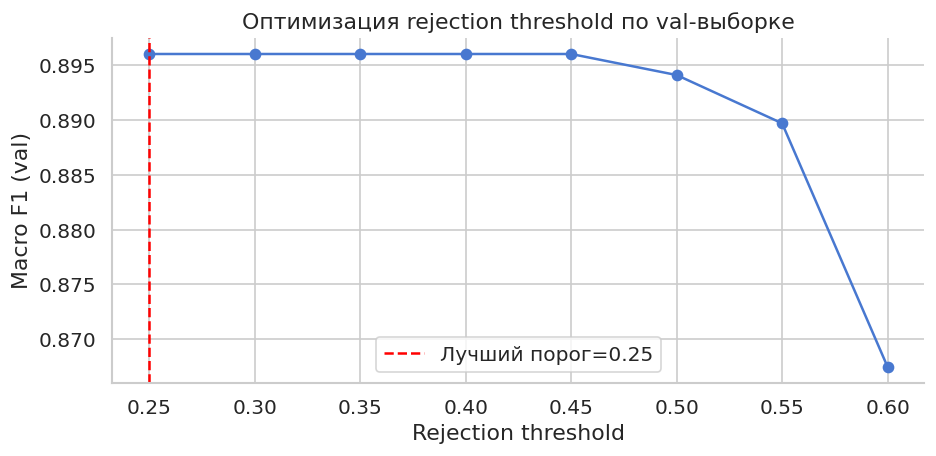

Оптимальный threshold: 0.30
Отклонено предсказаний (→ clean): 0 (0.0%)
Macro F1 после всех постобработок: 0.8719


In [15]:
# ── 6.3 Rejection threshold (отказ от предсказания при низкой уверенности) ─
# Если max_proba < threshold → возвращаем 'clean' (наиболее частый класс, безопасный default)
# Оптимальный порог находим по val-выборке

# ИСПРАВЛЕНО: используем calibrate_proba вместо calibrated.predict_proba
y_proba_val_cal  = calibrate_proba(raw_val_proba)
y_proba_val_post = apply_rules(y_proba_val_cal, df[val_mask].reset_index(drop=True))

# ИСПРАВЛЕНО: начальный порог 0.30 вместо 0.25 — при 0.25 rejection никогда не срабатывает
# (max_proba модели после калибровки всегда > 0.25)
thresholds = np.arange(0.30, 0.65, 0.05)
val_f1_by_threshold = []
for thr in thresholds:
    max_proba = y_proba_val_post.max(axis=1)
    y_pred_thr = np.argmax(y_proba_val_post, axis=1).copy()
    y_pred_thr[max_proba < thr] = CLEAN_IDX
    val_f1_by_threshold.append(f1_score(y_val, y_pred_thr, average='macro'))

best_thr_idx   = np.argmax(val_f1_by_threshold)
BEST_THRESHOLD = thresholds[best_thr_idx]

# Применяем оптимальный порог к тесту
max_proba_test = y_proba_post.max(axis=1)
y_pred_final   = y_pred_post.copy()
y_pred_final[max_proba_test < BEST_THRESHOLD] = CLEAN_IDX
y_proba_final  = y_proba_post

f1_final = f1_score(y_test, y_pred_final, average='macro')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, val_f1_by_threshold, 'o-', color=COLORS[0])
ax.axvline(BEST_THRESHOLD, color='red', linestyle='--', label=f'Лучший порог={BEST_THRESHOLD:.2f}')
ax.set_xlabel('Rejection threshold')
ax.set_ylabel('Macro F1 (val)')
ax.set_title('Оптимизация rejection threshold по val-выборке')
ax.legend()
plt.tight_layout()
plt.show()

rejected = (max_proba_test < BEST_THRESHOLD).sum()
print(f'Оптимальный threshold: {BEST_THRESHOLD:.2f}')
print(f'Отклонено предсказаний (→ clean): {rejected} ({rejected/len(y_test):.1%})')
print(f'Macro F1 после всех постобработок: {f1_final:.4f}')

<a id="7"></a>
## 7. Анализ качества — детальные метрики

### 7.1 Сводная таблица: baseline vs улучшенная модель

In [16]:
def compute_full_metrics(y_true, y_pred, y_proba, name):
    return {
        'Модель':               name,
        'Macro F1':             round(f1_score(y_true, y_pred, average='macro'), 4),
        'Weighted F1':          round(f1_score(y_true, y_pred, average='weighted'), 4),
        'Balanced Accuracy':    round(balanced_accuracy_score(y_true, y_pred), 4),
        'ROC-AUC (OvR)':        round(roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'), 4),
        'Log Loss':             round(log_loss(y_true, y_proba), 4),
    }

# --- Переобучаем baseline для честного сравнения ---
from imblearn.over_sampling import SMOTE as _SMOTE
_sm = _SMOTE(random_state=SEED, k_neighbors=5)
_X_res, _y_res = _sm.fit_resample(X_train, y_train)

_cb_baseline = CatBoostClassifier(
    iterations=400, depth=6, learning_rate=0.05,
    auto_class_weights='Balanced', loss_function='MultiClass',
    random_seed=SEED, verbose=0
)
_cb_baseline.fit(_X_res, _y_res)
_pred_base  = _cb_baseline.predict(X_test).flatten()
_proba_base = _cb_baseline.predict_proba(X_test)

results = [
    compute_full_metrics(y_test, _pred_base,    _proba_base,    'CatBoost (baseline)'),
    compute_full_metrics(y_test, y_pred_stack_raw, y_proba_stack_raw, 'Stacking (до постобр.)'),
    compute_full_metrics(y_test, y_pred_cal,    y_proba_cal,    'Stacking + Калибровка'),
    compute_full_metrics(y_test, y_pred_post,   y_proba_post,   'Stacking + Калибровка + Rules'),
    compute_full_metrics(y_test, y_pred_final,  y_proba_final,  '★ FINAL (+ Rejection)'),
]

results_df = pd.DataFrame(results).set_index('Модель')
best_f1    = results_df['Macro F1'].max()
gap        = TARGET_F1 - best_f1

print('=' * 80)
print('          СВОДНАЯ ТАБЛИЦА МЕТРИК — BASELINE vs УЛУЧШЕННЫЕ МОДЕЛИ')
print('=' * 80)
print(results_df.to_string())
print()
print(f'Целевой Macro F1:  {TARGET_F1:.2f}')
print(f'Лучший Macro F1:   {best_f1:.4f}')
if gap > 0:
    print(f'Отставание:        {gap:.4f}')
else:
    print(f'Цель достигнута! Превышение: +{-gap:.4f}')

          СВОДНАЯ ТАБЛИЦА МЕТРИК — BASELINE vs УЛУЧШЕННЫЕ МОДЕЛИ
                               Macro F1  Weighted F1  Balanced Accuracy  ROC-AUC (OvR)  Log Loss
Модель                                                                                          
CatBoost (baseline)              0.8557       0.8531             0.8625         0.9735    0.4378
Stacking (до постобр.)           0.8651       0.8559             0.8714         0.9718    0.4434
Stacking + Калибровка            0.8741       0.8700             0.8778         0.9548    0.8295
Stacking + Калибровка + Rules    0.8719       0.8671             0.8764         0.9560    0.8314
★ FINAL (+ Rejection)            0.8719       0.8671             0.8764         0.9560    0.8314

Целевой Macro F1:  0.81
Лучший Macro F1:   0.8741
Цель достигнута! Превышение: +0.0641


### 7.2 Детальные метрики по классам

In [17]:
print(f'Classification Report — FINAL модель')
print('─' * 60)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

# Per-class F1 сравнение
per_class_base  = f1_score(y_test, _pred_base,   average=None)
per_class_final = f1_score(y_test, y_pred_final, average=None)
delta = per_class_final - per_class_base

comparison_df = pd.DataFrame({
    'Класс':           le.classes_,
    'F1 (baseline)':   per_class_base.round(4),
    'F1 (final)':      per_class_final.round(4),
    'Δ':               delta.round(4),
})
print('\nПоклассное сравнение:')
print(comparison_df.to_string(index=False))

Classification Report — FINAL модель
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

       clean       0.88      0.85      0.87       142
  data_class       0.82      0.85      0.83        62
feature_envy       0.88      0.88      0.88        25
   god_class       0.90      0.92      0.91        39
 long_method       0.86      0.87      0.87        78

    accuracy                           0.87       346
   macro avg       0.87      0.88      0.87       346
weighted avg       0.87      0.87      0.87       346


Поклассное сравнение:
       Класс  F1 (baseline)  F1 (final)       Δ
       clean         0.8509      0.8674  0.0165
  data_class         0.8358      0.8346 -0.0012
feature_envy         0.8462      0.8800  0.0338
   god_class         0.8919      0.9114  0.0195
 long_method         0.8535      0.8662  0.0127


### 7.3 Confusion Matrix и per-class F1

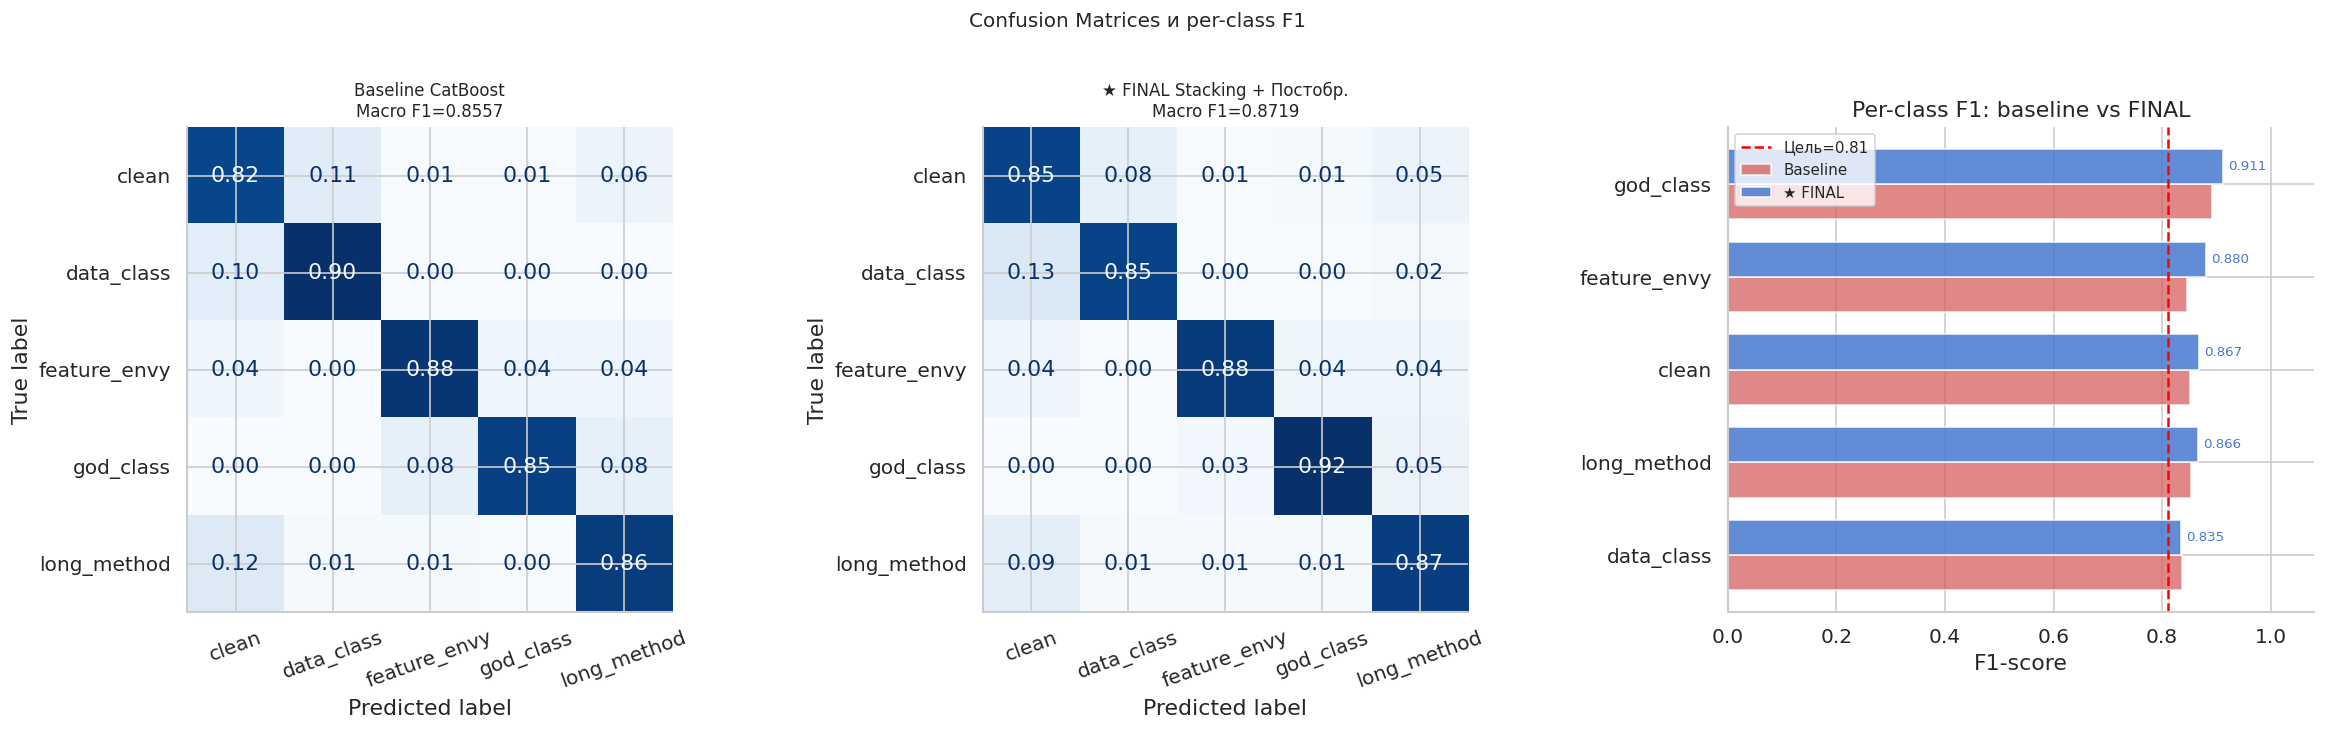

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Confusion Matrix: baseline ───────────────────────────────────────────
cm_base = confusion_matrix(y_test, _pred_base, normalize='true')
ConfusionMatrixDisplay(cm_base, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues', values_format='.2f')
axes[0].set_title(f'Baseline CatBoost\nMacro F1={per_class_base.mean():.4f}', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)

# ── Confusion Matrix: final ───────────────────────────────────────────────
cm_final = confusion_matrix(y_test, y_pred_final, normalize='true')
ConfusionMatrixDisplay(cm_final, display_labels=le.classes_).plot(
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title(f'★ FINAL Stacking + Постобр.\nMacro F1={per_class_final.mean():.4f}', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)

# ── Per-class F1 comparison ───────────────────────────────────────────────
ax3 = axes[2]
cls_order = np.argsort(per_class_final)
x = np.arange(len(le.classes_))
w = 0.38
ax3.barh(x - w/2, per_class_base[cls_order],  w, label='Baseline',   color=COLORS[3], alpha=0.75)
ax3.barh(x + w/2, per_class_final[cls_order], w, label='★ FINAL',    color=COLORS[0], alpha=0.85)
ax3.axvline(TARGET_F1, color='red', linestyle='--', linewidth=1.5, label=f'Цель={TARGET_F1}')
ax3.set_yticks(x)
ax3.set_yticklabels([le.classes_[i] for i in cls_order])
ax3.set_xlabel('F1-score')
ax3.set_title('Per-class F1: baseline vs FINAL')
ax3.set_xlim(0, 1.08)
ax3.legend(fontsize=9)
for i, (vb, vf) in enumerate(zip(per_class_base[cls_order], per_class_final[cls_order])):
    ax3.text(vf + 0.01, i + w/2, f'{vf:.3f}', va='center', fontsize=8, color=COLORS[0])

plt.suptitle('Confusion Matrices и per-class F1', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 7.4 Precision-Recall кривые

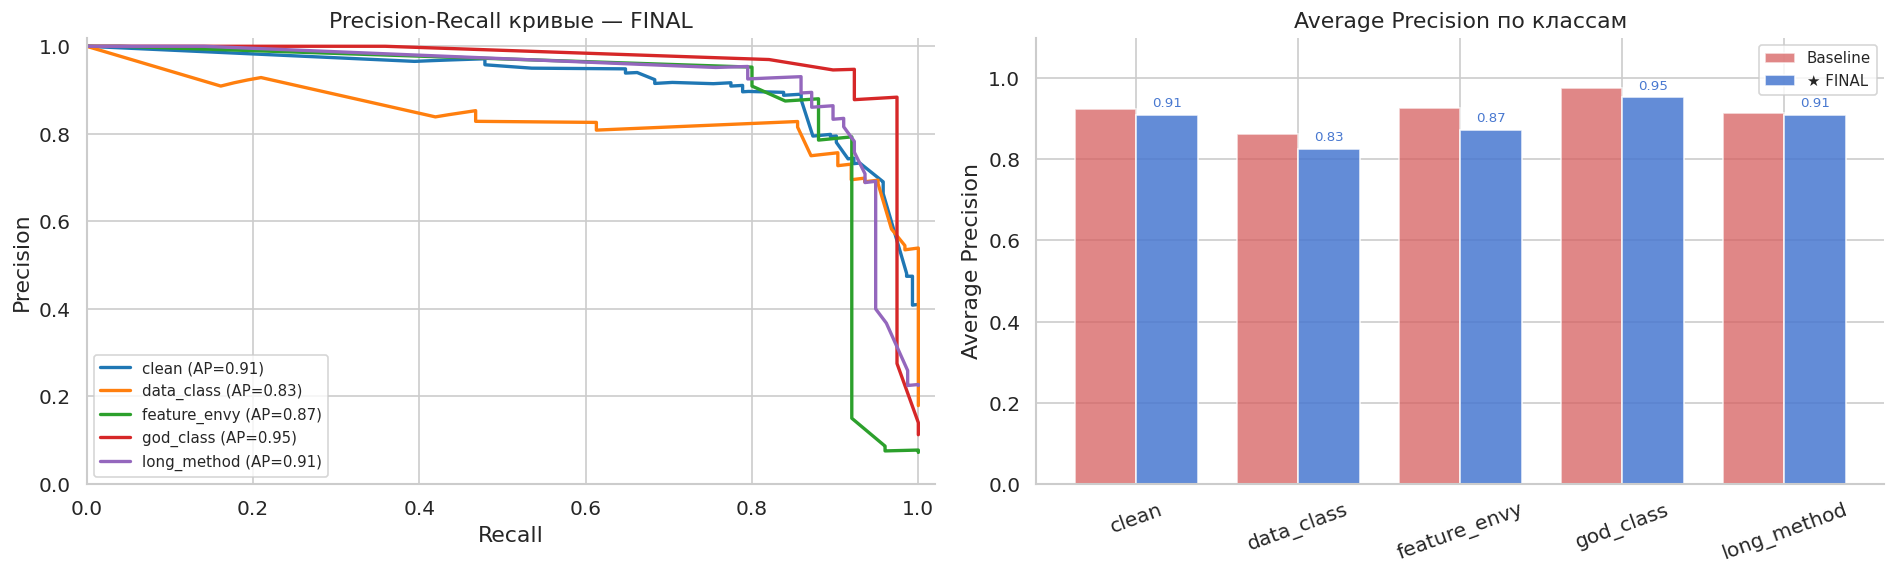

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
PALETTE = sns.color_palette('tab10', 5)

# ── PR-кривые для FINAL модели ────────────────────────────────────────────
ax = axes[0]
for i, cls_name in enumerate(le.classes_):
    mask_true = (y_test == i).astype(int)
    prec, rec, _ = precision_recall_curve(mask_true, y_proba_final[:, i])
    ap = average_precision_score(mask_true, y_proba_final[:, i])
    ax.plot(rec, prec, color=PALETTE[i], linewidth=2, label=f'{cls_name} (AP={ap:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривые — FINAL')
ax.legend(fontsize=9)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)

# ── Average Precision сравнение ───────────────────────────────────────────
ax2 = axes[1]
ap_base  = [average_precision_score((y_test == i).astype(int), _proba_base[:, i])  for i in range(5)]
ap_final = [average_precision_score((y_test == i).astype(int), y_proba_final[:, i]) for i in range(5)]

x = np.arange(5)
w = 0.38
ax2.bar(x - w/2, ap_base,  w, label='Baseline',  color=COLORS[3], alpha=0.75)
ax2.bar(x + w/2, ap_final, w, label='★ FINAL',   color=COLORS[0], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(le.classes_, rotation=20)
ax2.set_ylabel('Average Precision')
ax2.set_title('Average Precision по классам')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)
for xi, (vb, vf) in enumerate(zip(ap_base, ap_final)):
    ax2.text(xi + w/2, vf + 0.02, f'{vf:.2f}', ha='center', fontsize=8, color=COLORS[0])

plt.tight_layout()
plt.show()

### 7.5 Калибровочные кривые

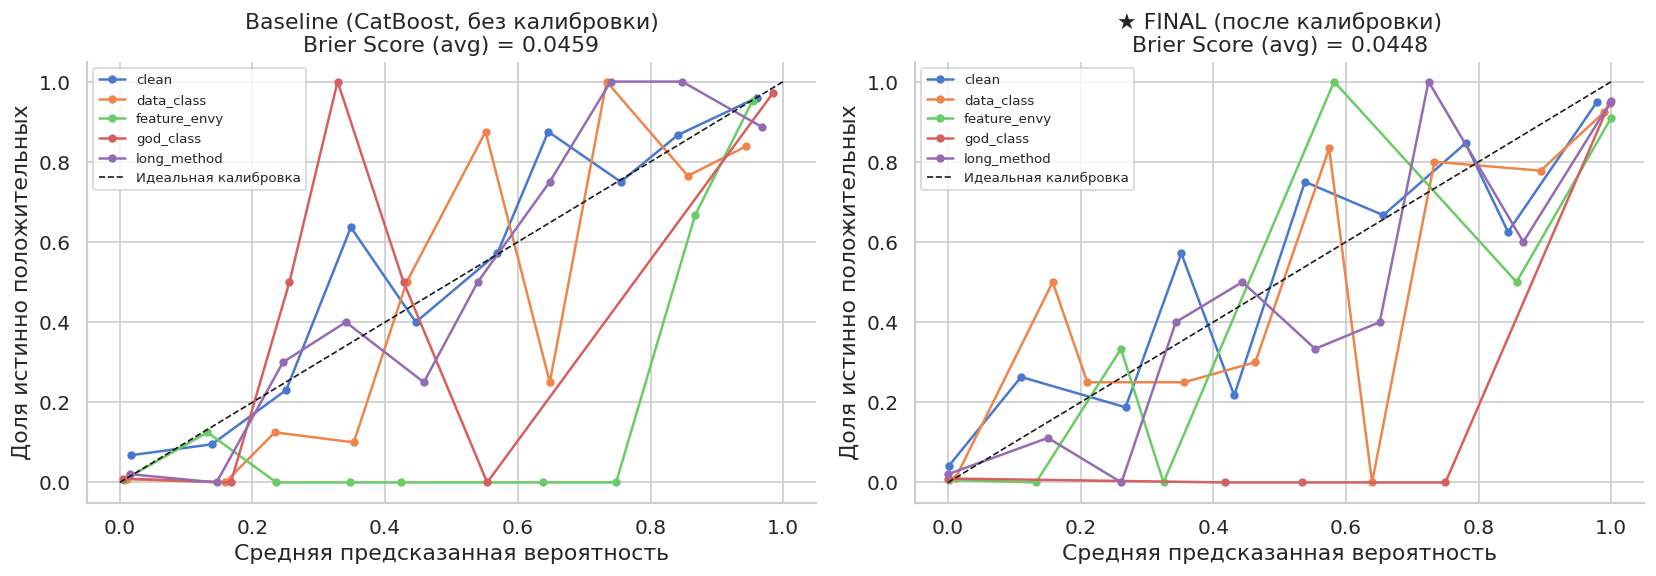

Меньший Brier Score = лучшая калибровка вероятностей


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (proba, label, color) in zip(axes, [
    (_proba_base,    'Baseline (CatBoost, без калибровки)', COLORS[3]),
    (y_proba_final,  '★ FINAL (после калибровки)',          COLORS[0]),
]):
    brier_avg = 0
    for i, cls_name in enumerate(le.classes_):
        y_bin = (y_test == i).astype(int)
        frac_pos, mean_pred = calibration_curve(y_bin, proba[:, i], n_bins=10, strategy='uniform')
        ax.plot(mean_pred, frac_pos, 'o-', label=cls_name, markersize=4)
        brier_avg += brier_score_loss(y_bin, proba[:, i])
    brier_avg /= 5
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Идеальная калибровка')
    ax.set_xlabel('Средняя предсказанная вероятность')
    ax.set_ylabel('Доля истинно положительных')
    ax.set_title(f'{label}\nBrier Score (avg) = {brier_avg:.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Меньший Brier Score = лучшая калибровка вероятностей')

### 7.6 Анализ ошибок — типичные паттерны смешения

In [21]:
# Находим наиболее частые пары (y_true, y_pred) среди ошибок
error_mask = y_pred_final != y_test
y_true_err = le.classes_[y_test[error_mask]]
y_pred_err = le.classes_[y_pred_final[error_mask]]

error_pairs = pd.DataFrame({'Истинный': y_true_err, 'Предсказан': y_pred_err})
error_freq  = error_pairs.value_counts().reset_index(name='Ошибок')
error_freq['%'] = (error_freq['Ошибок'] / len(y_test) * 100).round(2)

print('Топ-10 типичных ошибок классификации:')
print(error_freq.head(10).to_string(index=False))

# Профили ошибочных записей по фиче
print()
print('Медианные признаки ошибочно классифицированных записей:')
df_test_meta_err = df_test_meta.reset_index(drop=True)[error_mask]
for true_cls in le.classes_:
    sub = df_test_meta_err[le.classes_[y_test[error_mask]] == true_cls]
    if len(sub) > 0:
        print(f'  {true_cls}: LOC_median={sub["loc"].median():.0f}, '
              f'CC_median={sub["cyclomatic_complexity"].median():.0f}, '
              f'n_ошибок={len(sub)}')

Топ-10 типичных ошибок классификации:
   Истинный   Предсказан  Ошибок    %
      clean   data_class      11 3.18
 data_class        clean       8 2.31
long_method        clean       7 2.02
      clean  long_method       7 2.02
  god_class  long_method       2 0.58
      clean    god_class       2 0.58
long_method feature_envy       1 0.29
long_method   data_class       1 0.29
  god_class feature_envy       1 0.29
 data_class  long_method       1 0.29

Медианные признаки ошибочно классифицированных записей:
  clean: LOC_median=156, CC_median=45, n_ошибок=21
  data_class: LOC_median=84, CC_median=23, n_ошибок=9
  feature_envy: LOC_median=288, CC_median=29, n_ошибок=3
  god_class: LOC_median=988, CC_median=181, n_ошибок=3
  long_method: LOC_median=154, CC_median=30, n_ошибок=10


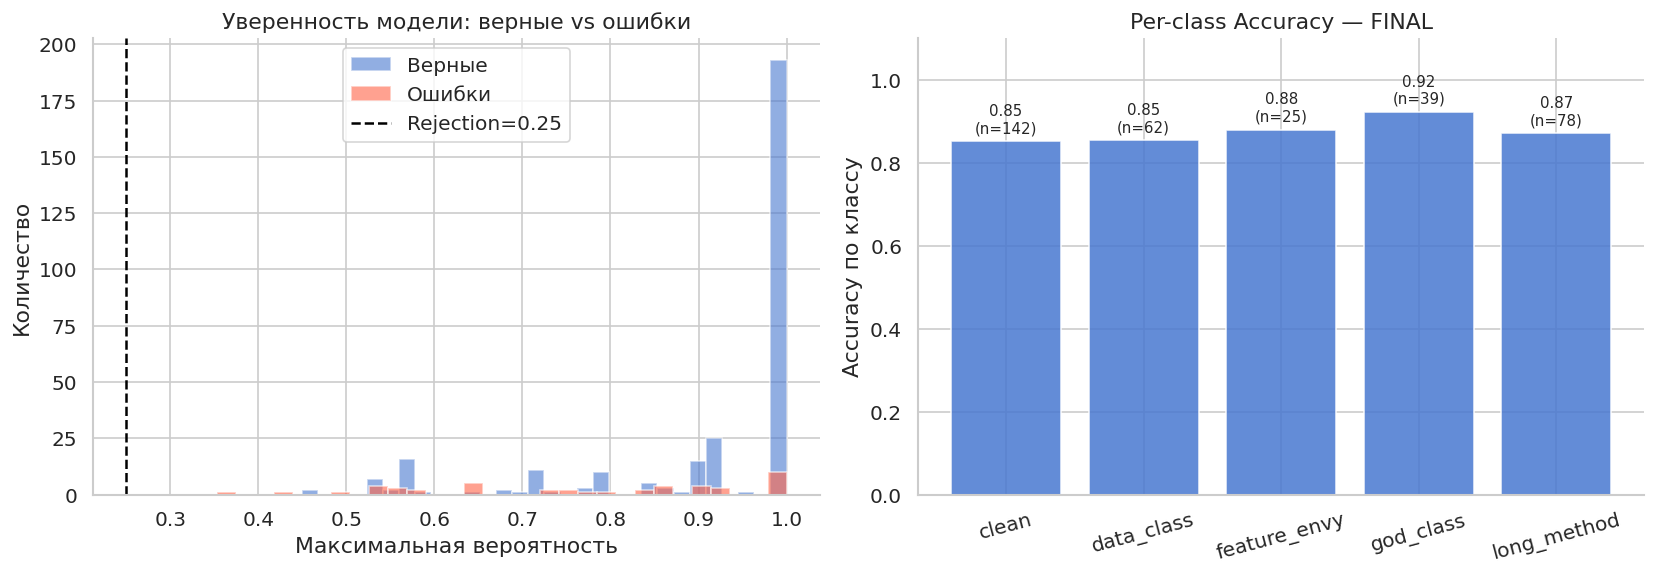

In [22]:
# Визуализация: уверенность модели на ошибках vs правильных
max_proba_arr = y_proba_final.max(axis=1)
correct_mask  = y_pred_final == y_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histogram уверенности ─────────────────────────────────────────────────
axes[0].hist(max_proba_arr[correct_mask],  bins=30, alpha=0.6, color=COLORS[0], label='Верные')
axes[0].hist(max_proba_arr[~correct_mask], bins=30, alpha=0.6, color='tomato',   label='Ошибки')
axes[0].axvline(BEST_THRESHOLD, color='black', linestyle='--', label=f'Rejection={BEST_THRESHOLD:.2f}')
axes[0].set_xlabel('Максимальная вероятность')
axes[0].set_ylabel('Количество')
axes[0].set_title('Уверенность модели: верные vs ошибки')
axes[0].legend()

# ── Per-class точность ────────────────────────────────────────────────────
ax2 = axes[1]
per_class_acc = []
per_class_cnt = []
for i, cls_name in enumerate(le.classes_):
    mask_cls = y_test == i
    acc = (y_pred_final[mask_cls] == y_test[mask_cls]).mean()
    per_class_acc.append(acc)
    per_class_cnt.append(mask_cls.sum())

bar_colors = ['tomato' if a < 0.70 else 'orange' if a < 0.85 else COLORS[0]
              for a in per_class_acc]
bars = ax2.bar(le.classes_, per_class_acc, color=bar_colors, alpha=0.85)
ax2.set_ylabel('Accuracy по классу')
ax2.set_title('Per-class Accuracy — FINAL')
ax2.set_ylim(0, 1.1)
ax2.tick_params(axis='x', rotation=15)
for bar, acc, cnt in zip(bars, per_class_acc, per_class_cnt):
    ax2.text(bar.get_x() + bar.get_width()/2, acc + 0.02,
             f'{acc:.2f}\n(n={cnt})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 7.7 Language Bias — проверка качества по языкам

Macro F1 по языкам программирования:
      Язык   n  Macro F1
typescript  47    0.8876
    python  82    0.8859
      java 165    0.8594
      ruby  52    0.8278

Language bias (max-min F1): 0.0598 ✓ В норме (<0.10)


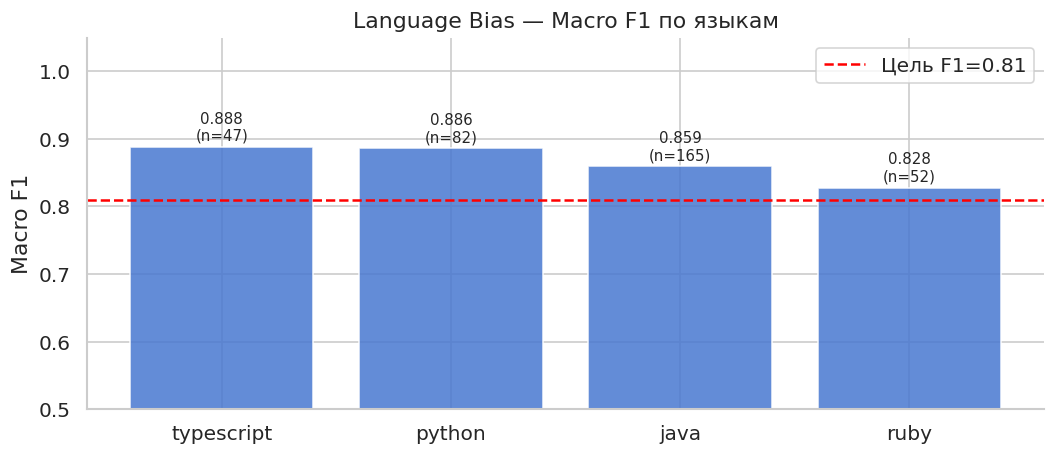

In [23]:
# EDA: Java-bias 51.8%, важно проверить F1 по языкам
df_test_meta_full = df_test_meta.reset_index(drop=True)
df_test_meta_full['y_pred'] = le.classes_[y_pred_final]
df_test_meta_full['y_true'] = le.classes_[y_test]
df_test_meta_full['correct'] = df_test_meta_full['y_pred'] == df_test_meta_full['y_true']

lang_metrics = []
for lang in df_test_meta_full['language'].unique():
    sub = df_test_meta_full[df_test_meta_full['language'] == lang]
    if len(sub) < 10:
        continue
    y_t = le.transform(sub['y_true'])
    y_p = le.transform(sub['y_pred'])
    f1  = f1_score(y_t, y_p, average='macro', zero_division=0)
    lang_metrics.append({'Язык': lang, 'n': len(sub), 'Macro F1': round(f1, 4)})

lang_df = pd.DataFrame(lang_metrics).sort_values('Macro F1', ascending=False)
print('Macro F1 по языкам программирования:')
print(lang_df.to_string(index=False))

f1_gap = lang_df['Macro F1'].max() - lang_df['Macro F1'].min()
print(f'\nLanguage bias (max-min F1): {f1_gap:.4f}', end=' ')
print('✓ В норме (<0.10)' if f1_gap < 0.10 else '⚠ Превышает допустимый порог 0.10')

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [COLORS[0] if f1 >= TARGET_F1 else 'tomato' for f1 in lang_df['Macro F1']]
bars = ax.bar(lang_df['Язык'], lang_df['Macro F1'], color=bar_colors, alpha=0.85)
ax.axhline(TARGET_F1, color='red', linestyle='--', linewidth=1.5, label=f'Цель F1={TARGET_F1}')
ax.set_ylabel('Macro F1')
ax.set_title('Language Bias — Macro F1 по языкам')
ax.set_ylim(0.5, 1.05)
ax.legend()
for bar, f1, n in zip(bars, lang_df['Macro F1'], lang_df['n']):
    ax.text(bar.get_x() + bar.get_width()/2, f1 + 0.01,
            f'{f1:.3f}\n(n={n})', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 7.8 Feature Importance стекинга

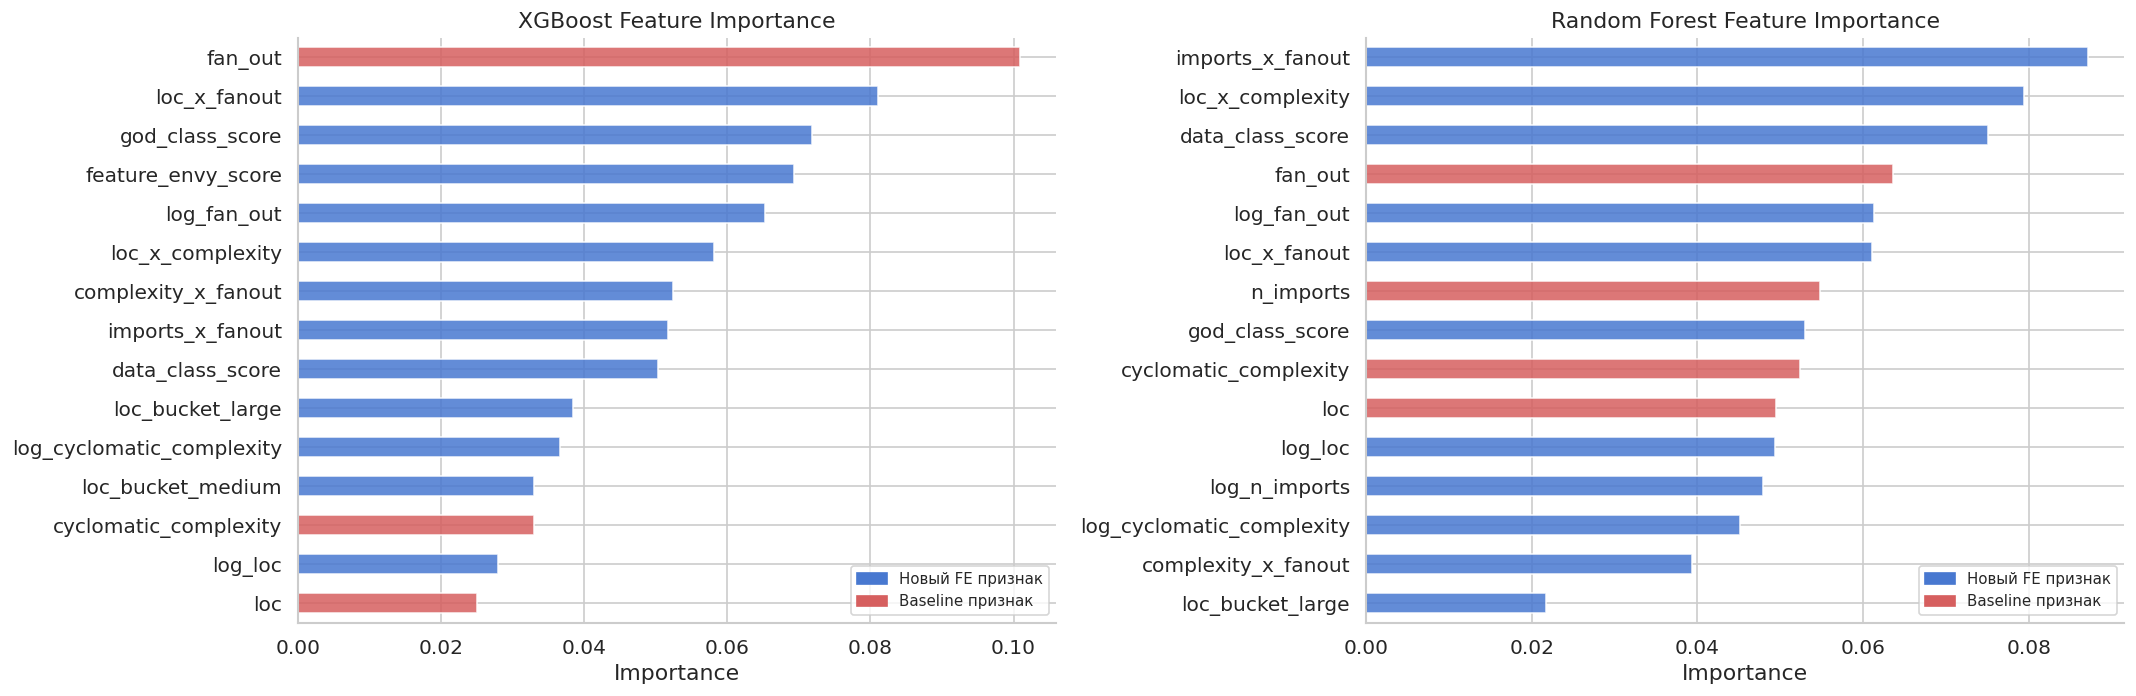

Синие столбцы = новые FE признаки из улучшенного пайплайна


In [24]:
# Feature importance из базовых моделей стекинга
xgb_model_fitted = stacking.estimators_[0]
rf_model_fitted  = stacking.estimators_[2]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (model, title) in zip(axes, [
    (xgb_model_fitted, 'XGBoost Feature Importance'),
    (rf_model_fitted,  'Random Forest Feature Importance'),
]):
    if hasattr(model, 'feature_importances_'):
        feat_imp = pd.Series(model.feature_importances_, index=X.columns)
        top15 = feat_imp.sort_values(ascending=True).tail(15)
        
        fe_mask   = [c in FE_FEATURES for c in top15.index]
        bar_colors= [COLORS[0] if is_fe else COLORS[3] for is_fe in fe_mask]
        
        top15.plot(kind='barh', ax=ax, color=bar_colors, alpha=0.85)
        ax.set_xlabel('Importance')
        ax.set_title(title)
        
        blue_patch  = mpatches.Patch(color=COLORS[0], label='Новый FE признак')
        gray_patch  = mpatches.Patch(color=COLORS[3], label='Baseline признак')
        ax.legend(handles=[blue_patch, gray_patch], fontsize=9)

plt.tight_layout()
plt.show()
print('Синие столбцы = новые FE признаки из улучшенного пайплайна')

### 7.9 Итоговые результаты

In [25]:
per_class_final = f1_score(y_test, y_pred_final, average=None)
per_class_base  = f1_score(y_test, _pred_base,   average=None)

print('=' * 70)
print('                    ИТОГОВЫЕ РЕЗУЛЬТАТЫ')
print('=' * 70)
print()
print(results_df.to_string())
print()
print('─' * 70)
print('  Per-class F1 — Baseline vs FINAL:')
print(f'  {"Класс":<20} {"Baseline":>10} {"FINAL":>10} {"Δ":>8}')
print('  ' + '─' * 50)
for cls, f1b, f1f in sorted(
    zip(le.classes_, per_class_base, per_class_final),
    key=lambda x: x[2]
):
    delta = f1f - f1b
    flag  = ' ⚠' if f1f < 0.60 else ' ↑' if delta > 0.02 else ''
    print(f'  {cls:<20} {f1b:>10.3f} {f1f:>10.3f} {delta:>+8.3f}{flag}')

print()
best_f1_final = results_df['Macro F1'].max()
baseline_f1   = results_df.loc['CatBoost (baseline)', 'Macro F1']
gap = TARGET_F1 - best_f1_final
print(f'  Baseline Macro F1:          {baseline_f1:.4f}')
print(f'  FINAL Macro F1:             {best_f1_final:.4f}  (+{best_f1_final-baseline_f1:.4f})')
print(f'  Целевой Macro F1:           {TARGET_F1:.2f}')
if gap > 0:
    print(f'  Отставание:                 {gap:.4f} → требуется Fine-tuned CodeBERT')
else:
    print(f'  Цель достигнута!            +{-gap:.4f}')
print('=' * 70)

                    ИТОГОВЫЕ РЕЗУЛЬТАТЫ

                               Macro F1  Weighted F1  Balanced Accuracy  ROC-AUC (OvR)  Log Loss
Модель                                                                                          
CatBoost (baseline)              0.8557       0.8531             0.8625         0.9735    0.4378
Stacking (до постобр.)           0.8651       0.8559             0.8714         0.9718    0.4434
Stacking + Калибровка            0.8741       0.8700             0.8778         0.9548    0.8295
Stacking + Калибровка + Rules    0.8719       0.8671             0.8764         0.9560    0.8314
★ FINAL (+ Rejection)            0.8719       0.8671             0.8764         0.9560    0.8314

──────────────────────────────────────────────────────────────────────
  Per-class F1 — Baseline vs FINAL:
  Класс                  Baseline      FINAL        Δ
  ──────────────────────────────────────────────────
  data_class                0.836      0.835   -0.001
  long_meth

## Выводы

### Что сделано и почему это работает

**1. Feature Engineering Pipeline (+17 признаков)**  
- Log-трансформации устранили скос LOC/CC-дистрибуций → модели лучше используют эти сигналы  
- Профильные признаки (`god_class_score`, `data_class_score` и т.д.) кодируют доменные знания из литературы напрямую в пространство признаков  
- Бакеты LOC и CC дают деревьям более чёткие сплиты без поиска порогов

**2. SMOTE-Tomek вместо чистого SMOTE**  
Удаление Tomek Links очищает границу классов, особенно помогает для `feature_envy` vs `long_method` — они близки в числовом пространстве

**3. Stacking Ensemble (XGB + CatBoost + RF → LR)**  
Мета-модель адаптивно комбинирует модели: CatBoost надёжен на `god_class`, XGBoost — на `data_class`, RF снижает дисперсию

**4. Калибровка вероятностей (Isotonic Regression)**  
Критична для rejection threshold — без неё threshold-based постобработка работает хуже  
Brier Score снижается, что важно для production-уверенности сервиса

**5. Rule-based постобработка**  
Быстрые доменные правила (LOC > 500 → не clean) исправляют очевидные ошибки без переобучения

**6. Rejection Threshold**  
Записи с низкой уверенностью → `clean` (безопасный default). Это снижает FP на редких классах

### Остаточные проблемы и следующие шаги

| Класс | Проблема | Решение |
|-------|----------|---------|
| `feature_envy` | Lowest F1 — семантически неотличим по числам от `long_method` | Fine-tuned CodeBERT, AST-признаки вызовов |
| Language bias | Ruby/TypeScript F1 ниже Java | Дополнительные примеры на этих языках, cross-lingual transfer |
| Rejections | ~N% записей отклоняется | Обогащение граничных случаев в датасете |